In [392]:
import os
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split, KFold
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
import json

In [393]:
stage = "river"

### Reading and compacting dfs

In [394]:
compact = False

In [395]:
# Iterate over files in dfs/*.parquet and combine to one df
dfs = []

read = []
for file in os.listdir('dfs'):
    if file.endswith('.parquet'):
        read.append(file)
        df = pd.read_parquet(f"dfs/{file}")
        dfs.append(df)

raw_df = pd.concat(dfs, ignore_index=True)

if compact and len(dfs) > 0:
    print("Compacintg dfs")
    # Move read files to trash and write combined df to dfs/combined_{timestamp}.parquet
    trash = 'dfs/trash'
    for f in read:
        os.rename(f'dfs/{f}', f'{trash}/{f}')

    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    raw_df.to_parquet(f'dfs/compacted_{timestamp}.parquet')

raw_df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size,stage
0,0.000949,0.001175,0.000867,0.001118,0.000547,0.000335,0.000376,0.000019,0.000609,0.000970,...,0,224,65,289,True,False,True,513,1496,river
1,0.000953,0.000382,0.001230,0.000696,0.000345,0.000526,0.000573,0.000548,0.000306,0.001121,...,0,216,47,263,True,False,True,479,1431,river
2,0.000599,0.000679,0.000011,0.001274,0.000049,0.000294,0.001106,0.000297,0.000436,0.000799,...,0,406,151,557,True,False,True,963,1930,river
3,0.000326,0.000179,0.000722,0.000766,0.000419,0.000994,0.000819,0.001090,0.000313,0.000129,...,0,389,77,466,True,False,True,855,2236,river
4,0.000474,0.001348,0.000230,0.000934,0.000944,0.001230,0.000413,0.000513,0.000326,0.000888,...,0,434,63,497,True,False,True,931,2612,river
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
546,0.000606,0.000134,0.000044,0.001506,0.000911,0.000148,0.000991,0.001004,0.001256,0.001168,...,108,226,198,316,True,True,True,542,2083,river
547,0.001264,0.000755,0.000916,0.000563,0.000142,0.000096,0.000540,0.001188,0.001201,0.000580,...,0,384,189,573,True,False,True,957,2419,river
548,0.000171,0.000525,0.000313,0.001181,0.000674,0.000659,0.001246,0.000157,0.000905,0.000312,...,253,635,515,897,True,True,True,1532,2894,river
549,0.000262,0.000291,0.000953,0.001247,0.000777,0.000546,0.001030,0.001214,0.001298,0.000451,...,0,280,0,280,True,False,False,560,2284,river


In [396]:
df = raw_df[raw_df["stage"] == stage]
df = df.drop(columns=["stage"])
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size
0,0.000949,0.001175,0.000867,0.001118,0.000547,0.000335,0.000376,0.000019,0.000609,0.000970,...,0.0,0,224,65,289,True,False,True,513,1496
1,0.000953,0.000382,0.001230,0.000696,0.000345,0.000526,0.000573,0.000548,0.000306,0.001121,...,0.0,0,216,47,263,True,False,True,479,1431
2,0.000599,0.000679,0.000011,0.001274,0.000049,0.000294,0.001106,0.000297,0.000436,0.000799,...,0.0,0,406,151,557,True,False,True,963,1930
3,0.000326,0.000179,0.000722,0.000766,0.000419,0.000994,0.000819,0.001090,0.000313,0.000129,...,0.0,0,389,77,466,True,False,True,855,2236
4,0.000474,0.001348,0.000230,0.000934,0.000944,0.001230,0.000413,0.000513,0.000326,0.000888,...,0.0,0,434,63,497,True,False,True,931,2612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
546,0.000606,0.000134,0.000044,0.001506,0.000911,0.000148,0.000991,0.001004,0.001256,0.001168,...,0.0,108,226,198,316,True,True,True,542,2083
547,0.001264,0.000755,0.000916,0.000563,0.000142,0.000096,0.000540,0.001188,0.001201,0.000580,...,0.0,0,384,189,573,True,False,True,957,2419
548,0.000171,0.000525,0.000313,0.001181,0.000674,0.000659,0.001246,0.000157,0.000905,0.000312,...,0.0,253,635,515,897,True,True,True,1532,2894
549,0.000262,0.000291,0.000953,0.001247,0.000777,0.000546,0.001030,0.001214,0.001298,0.000451,...,0.0,0,280,0,280,True,False,False,560,2284


In [397]:
# Show all types of columns:
list(sorted(set(["_".join(col.split("_")[0:2]) for col in df.columns])))

['game_size',
 'opponent_bet',
 'opponent_has',
 'player_bet',
 'player_has',
 'player_turn',
 'pot',
 'prob_O',
 'prob_P',
 'public_card',
 'value_of']

### Preprocessing

In [398]:
# Divide all bets by game_size
bet_columns = [
    "player_bet_in_stage",
    "player_bet_in_game",
    "opponent_bet_in_stage",
    "opponent_bet_in_game",
    "pot",
]

def scale_bets(df):
    df[bet_columns] = df[bet_columns].div(df["game_size"], axis=0)
    return df


scale_bets(df)
df[bet_columns]

,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,pot
0,0.000000,0.149733,0.043449,0.193182,0.342914
1,0.000000,0.150943,0.032844,0.183788,0.334731
2,0.000000,0.210363,0.078238,0.288601,0.498964
3,0.000000,0.173971,0.034436,0.208408,0.382379
4,0.000000,0.166156,0.024119,0.190276,0.356432
...,...,...,...,...,...
546,0.051848,0.108497,0.095055,0.151704,0.260202
547,0.000000,0.158743,0.078131,0.236875,0.395618
548,0.087422,0.219419,0.177954,0.309952,0.529371
549,0.000000,0.122592,0.000000,0.122592,0.245184


In [399]:
# Scale range features so that the mean becomes 0 and the standard deviation becomes 1
range_columns = [col for col in df.columns if col.startswith("prob_")]
def scale_ranges(df, training_mean, training_sd):
    df[range_columns] = (df[range_columns] - training_mean) / training_sd
    return df

def get_training_range_mean_and_sd(df):
    return df[range_columns].to_numpy().mean(), df[range_columns].to_numpy().std()

def revert_range_scaling(df, training_mean, training_sd):
    df[range_columns] = df[range_columns] * training_sd + training_mean
    return df

mean_training_range_val, sd_training_range_val = get_training_range_mean_and_sd(df)
scale_ranges(df, mean_training_range_val, sd_training_range_val)
print("Original mean and sd of range features:")
print(mean_training_range_val, sd_training_range_val)
print("Mean and sd of range features after scaling:")
print(df[range_columns].to_numpy().mean(), df[range_columns].to_numpy().std())
df[range_columns]

Original mean and sd of range features:
0.0007541478129713427 0.0004351140468228343
Mean and sd of range features after scaling:
-8.135064978023281e-16 1.0000000000000002


,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,prob_O_has_hand_1316,prob_O_has_hand_1317,prob_O_has_hand_1318,prob_O_has_hand_1319,prob_O_has_hand_1320,prob_O_has_hand_1321,prob_O_has_hand_1322,prob_O_has_hand_1323,prob_O_has_hand_1324,prob_O_has_hand_1325
0,0.447202,0.967100,0.259622,0.837237,-0.476067,-0.963166,-0.868392,-1.689506,-0.332532,0.495754,...,0.602566,0.587143,0.073517,-1.345338,-1.719796,0.247945,-1.280418,-1.583966,-0.437378,1.292130
1,0.457191,-0.855908,1.093738,-0.134490,-0.939396,-0.523691,-0.416458,-0.472667,-1.029367,0.843890,...,-0.318527,-0.480276,0.571581,1.749441,-0.622081,0.202998,-0.352201,1.505722,-0.923248,-1.301159
2,-0.357675,-0.172453,-1.707424,1.195157,-1.620776,-1.057948,0.809435,-1.050394,-0.731152,0.102839,...,-0.898993,1.104102,1.482154,-0.360106,0.553865,0.343409,0.903307,0.752485,0.110099,-1.638358
3,-0.983960,-1.322584,-0.074620,0.026508,-0.769752,0.551619,0.148061,0.772551,-1.014125,-1.436574,...,0.934397,-1.533650,-0.739545,0.233396,-0.371322,-1.613204,-0.295281,0.021564,1.281580,-0.660629
4,-0.643557,1.364026,-1.205349,0.412727,0.437040,1.093268,-0.784198,-0.555340,-0.983753,0.306481,...,0.469914,-1.387396,-1.641567,1.524000,0.433613,-0.563881,-0.773133,-0.678302,-0.498060,0.079975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
546,-0.341241,-1.425214,-1.632116,1.727332,0.360692,-1.392709,0.544472,0.574969,1.153278,0.951373,...,-1.209452,0.761204,-0.054115,0.783263,1.296696,-0.250051,0.557234,-0.070826,1.246197,1.107842
547,1.171517,0.002052,0.371601,-0.438517,-1.407012,-1.512718,-0.491711,0.997483,1.026259,-0.400337,...,-0.463275,0.254813,1.375631,-0.592025,-1.418819,0.968208,0.171109,-0.100438,-0.134131,-1.192332
548,-1.339574,-0.526732,-1.014414,0.979867,-0.183578,-0.219370,1.130020,-1.373534,0.345682,-1.015370,...,-1.394154,0.266279,-0.997440,0.316726,0.245425,-0.481867,1.067442,-0.162776,-1.715438,-0.920699
549,-1.131081,-1.063946,0.456023,1.132573,0.051822,-0.478359,0.633656,1.057076,1.250214,-0.696148,...,1.304784,0.980841,0.678200,0.865068,-0.527837,1.153304,1.266505,1.020141,1.527168,1.581043


In [400]:
# Scale node values (target variable) so that the mean becomes 0 and the standard deviation becomes 1
value_columns = [col for col in df.columns if col.startswith("value_")]

"""
# Commented out, because we probably don't need it (target is already at scale [-1, 1])
def scale_values(df, training_mean, training_sd):
    df[value_columns] = (df[value_columns] - training_mean) / training_sd
    return df


def get_training_target_mean_and_sd(df):
    return df[value_columns].to_numpy().mean(), df[value_columns].to_numpy().std()


def revert_value_scaling(arr: np.array, training_mean, training_sd):
    return arr * training_sd + training_mean


mean_training_value_val, sd_training_value_val = get_training_target_mean_and_sd(df)
orig_values = df[value_columns]
scale_values(df, mean_training_value_val, sd_training_value_val)
print("Original mean and sd of values:")
print(orig_values.to_numpy().mean())
print(orig_values.to_numpy().std())
print("New mean and sd of values:")
print(df[value_columns].to_numpy().mean())
print(df[value_columns].to_numpy().std())
# Check revert function
assert np.allclose(
    revert_value_scaling(df, mean_training_value_val, sd_training_value_val)[
        value_columns
    ].to_numpy(),
    orig_values.to_numpy(),
)
df[value_columns] """
print("Mean of target variable:", df[value_columns].to_numpy().mean())
print("SD of target variable:", df[value_columns].to_numpy().std())
print("Min of target variable:", df[value_columns].to_numpy().min())
print("Max of target variable:", df[value_columns].to_numpy().max())
df[value_columns]

Mean of target variable: -0.0017605659038792871
SD of target variable: 0.11778776130607924
Min of target variable: -0.3554668813288401
Max of target variable: 0.5294530942395186


,value_of_hand_0,value_of_hand_1,value_of_hand_2,value_of_hand_3,value_of_hand_4,value_of_hand_5,value_of_hand_6,value_of_hand_7,value_of_hand_8,value_of_hand_9,...,value_of_hand_1316,value_of_hand_1317,value_of_hand_1318,value_of_hand_1319,value_of_hand_1320,value_of_hand_1321,value_of_hand_1322,value_of_hand_1323,value_of_hand_1324,value_of_hand_1325
0,-0.081638,-0.000498,-0.028550,-0.090864,0.070579,0.067363,0.060463,0.050083,0.000000,0.034855,...,-0.061026,0.024404,0.010037,0.001629,-0.062474,-0.065114,-0.067324,0.008741,0.000099,-0.002278
1,0.241291,-0.000329,0.202978,0.056633,0.032012,0.016464,0.005828,0.000817,-0.052290,-0.020656,...,0.000000,0.000000,-0.041838,-0.064753,0.000000,0.000000,0.000000,0.000000,0.000000,-0.047671
2,0.001929,0.379400,0.334204,-0.000464,-0.000783,-0.097363,-0.000641,0.000000,0.263324,0.077466,...,-0.000957,-0.000996,-0.000999,-0.017562,0.061099,0.032305,0.010830,0.025084,0.005923,0.005152
3,0.072178,0.000316,0.066442,-0.000460,0.059202,-0.010708,0.048682,0.032374,0.018234,0.005971,...,0.010835,0.002015,-0.045242,-0.066926,0.000951,-0.048285,-0.069988,-0.051346,-0.072479,-0.092398
4,0.000000,0.253612,0.221163,0.104365,-0.000647,0.000000,-0.030952,0.076358,0.051061,-0.051772,...,-0.092373,0.000000,0.016166,0.002134,0.000000,0.015301,0.002531,0.000000,0.000000,0.002380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
546,-0.065529,-0.073302,0.000000,0.000000,-0.079839,-0.087219,0.000000,-0.094099,-0.101385,-0.109734,...,0.137327,0.116258,0.095871,-0.026285,0.114424,0.094035,-0.027785,0.089407,-0.029130,-0.029462
547,0.019414,-0.000720,0.020095,0.019561,0.017655,-0.000759,-0.005162,-0.008029,0.015384,0.013418,...,-0.000522,-0.000502,-0.000530,-0.000580,-0.013092,0.047680,0.031739,0.046899,0.031036,0.027667
548,0.345951,0.344209,-0.026936,0.312363,0.264424,-0.058003,0.204619,0.000000,0.134436,-0.133568,...,-0.111460,0.000000,-0.221216,-0.114253,0.000000,-0.186473,-0.236552,0.000000,0.000000,-0.191652
549,-0.000602,-0.000032,-0.000031,-0.000032,-0.000032,-0.000033,-0.006720,-0.000734,-0.000820,-0.001093,...,-0.006043,-0.006186,-0.006406,-0.006517,-0.006129,-0.006348,-0.006460,-0.006431,-0.006542,-0.006653


In [401]:
# Make boolean features 0 or 1
def encode_bools(df):
    bool_columns = [
        "player_turn",
        "player_has_bet",
        "opponent_has_bet",
    ]
    df[bool_columns] = df[bool_columns].astype(int)
    return df

df = encode_bools(df)
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size
0,0.447202,0.967100,0.259622,0.837237,-0.476067,-0.963166,-0.868392,-1.689506,-0.332532,0.495754,...,0.0,0.000000,0.149733,0.043449,0.193182,1,0,1,0.342914,1496
1,0.457191,-0.855908,1.093738,-0.134490,-0.939396,-0.523691,-0.416458,-0.472667,-1.029367,0.843890,...,0.0,0.000000,0.150943,0.032844,0.183788,1,0,1,0.334731,1431
2,-0.357675,-0.172453,-1.707424,1.195157,-1.620776,-1.057948,0.809435,-1.050394,-0.731152,0.102839,...,0.0,0.000000,0.210363,0.078238,0.288601,1,0,1,0.498964,1930
3,-0.983960,-1.322584,-0.074620,0.026508,-0.769752,0.551619,0.148061,0.772551,-1.014125,-1.436574,...,0.0,0.000000,0.173971,0.034436,0.208408,1,0,1,0.382379,2236
4,-0.643557,1.364026,-1.205349,0.412727,0.437040,1.093268,-0.784198,-0.555340,-0.983753,0.306481,...,0.0,0.000000,0.166156,0.024119,0.190276,1,0,1,0.356432,2612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
546,-0.341241,-1.425214,-1.632116,1.727332,0.360692,-1.392709,0.544472,0.574969,1.153278,0.951373,...,0.0,0.051848,0.108497,0.095055,0.151704,1,1,1,0.260202,2083
547,1.171517,0.002052,0.371601,-0.438517,-1.407012,-1.512718,-0.491711,0.997483,1.026259,-0.400337,...,0.0,0.000000,0.158743,0.078131,0.236875,1,0,1,0.395618,2419
548,-1.339574,-0.526732,-1.014414,0.979867,-0.183578,-0.219370,1.130020,-1.373534,0.345682,-1.015370,...,0.0,0.087422,0.219419,0.177954,0.309952,1,1,1,0.529371,2894
549,-1.131081,-1.063946,0.456023,1.132573,0.051822,-0.478359,0.633656,1.057076,1.250214,-0.696148,...,0.0,0.000000,0.122592,0.000000,0.122592,1,0,0,0.245184,2284


In [402]:
# Drop game_size column
df = df.drop(columns=["game_size"])
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_50,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot
0,0.447202,0.967100,0.259622,0.837237,-0.476067,-0.963166,-0.868392,-1.689506,-0.332532,0.495754,...,0.0,0.0,0.000000,0.149733,0.043449,0.193182,1,0,1,0.342914
1,0.457191,-0.855908,1.093738,-0.134490,-0.939396,-0.523691,-0.416458,-0.472667,-1.029367,0.843890,...,0.0,0.0,0.000000,0.150943,0.032844,0.183788,1,0,1,0.334731
2,-0.357675,-0.172453,-1.707424,1.195157,-1.620776,-1.057948,0.809435,-1.050394,-0.731152,0.102839,...,0.0,0.0,0.000000,0.210363,0.078238,0.288601,1,0,1,0.498964
3,-0.983960,-1.322584,-0.074620,0.026508,-0.769752,0.551619,0.148061,0.772551,-1.014125,-1.436574,...,0.0,0.0,0.000000,0.173971,0.034436,0.208408,1,0,1,0.382379
4,-0.643557,1.364026,-1.205349,0.412727,0.437040,1.093268,-0.784198,-0.555340,-0.983753,0.306481,...,0.0,0.0,0.000000,0.166156,0.024119,0.190276,1,0,1,0.356432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
546,-0.341241,-1.425214,-1.632116,1.727332,0.360692,-1.392709,0.544472,0.574969,1.153278,0.951373,...,0.0,0.0,0.051848,0.108497,0.095055,0.151704,1,1,1,0.260202
547,1.171517,0.002052,0.371601,-0.438517,-1.407012,-1.512718,-0.491711,0.997483,1.026259,-0.400337,...,0.0,0.0,0.000000,0.158743,0.078131,0.236875,1,0,1,0.395618
548,-1.339574,-0.526732,-1.014414,0.979867,-0.183578,-0.219370,1.130020,-1.373534,0.345682,-1.015370,...,0.0,0.0,0.087422,0.219419,0.177954,0.309952,1,1,1,0.529371
549,-1.131081,-1.063946,0.456023,1.132573,0.051822,-0.478359,0.633656,1.057076,1.250214,-0.696148,...,0.0,0.0,0.000000,0.122592,0.000000,0.122592,1,0,0,0.245184


### Data validation

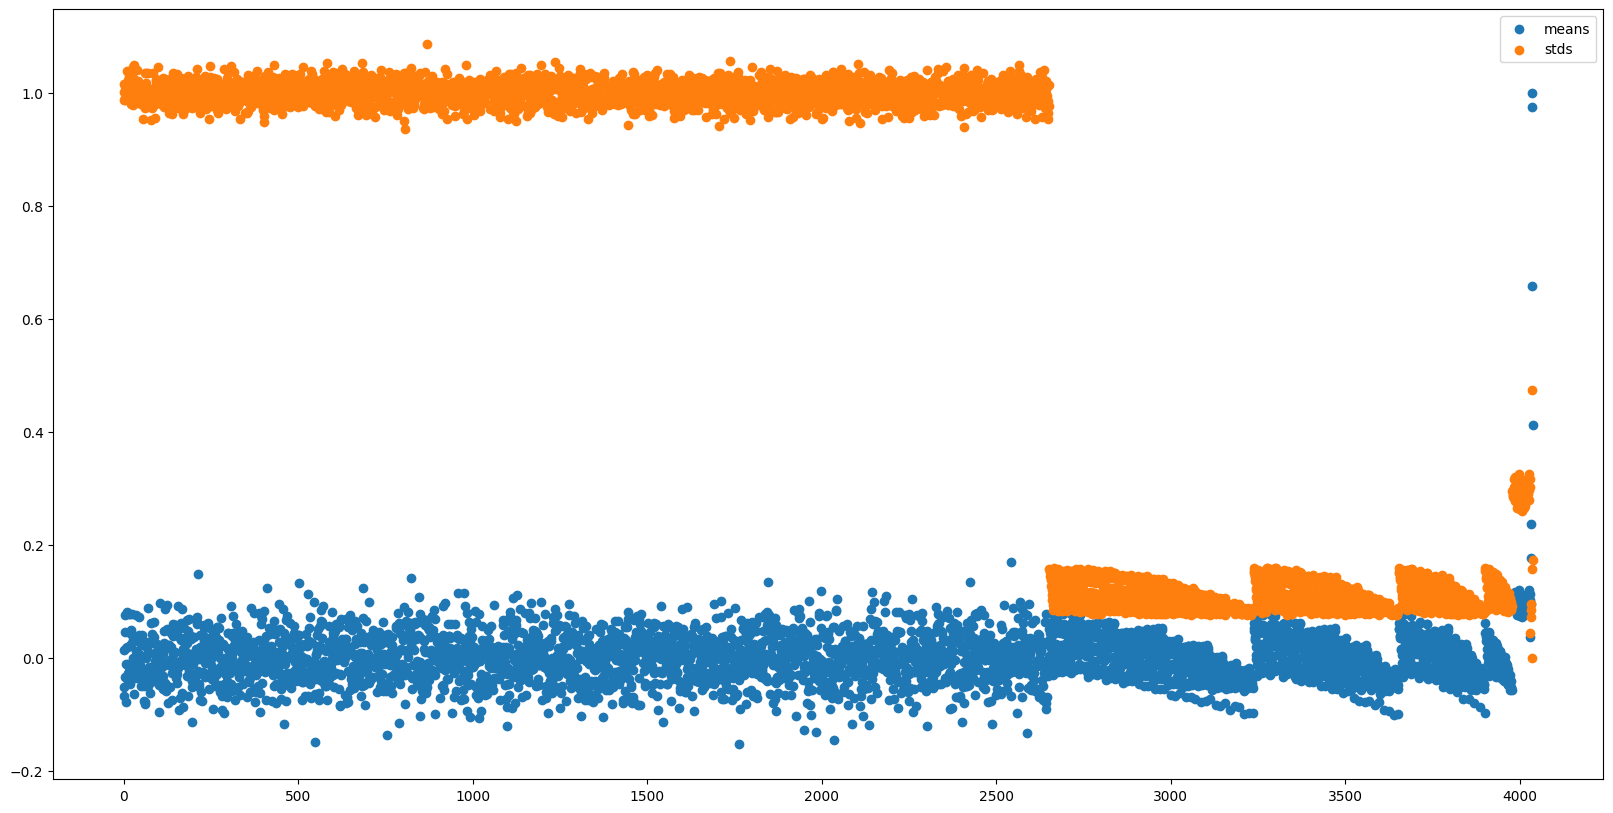

In [403]:
# Check that values are in correct range
fig, ax = plt.subplots(figsize=(20, 10))
plt.scatter(range(df.mean().size), df.mean(), label="means")
plt.scatter(range(df.std().size), df.std(), label="stds")
plt.legend()
plt.show()

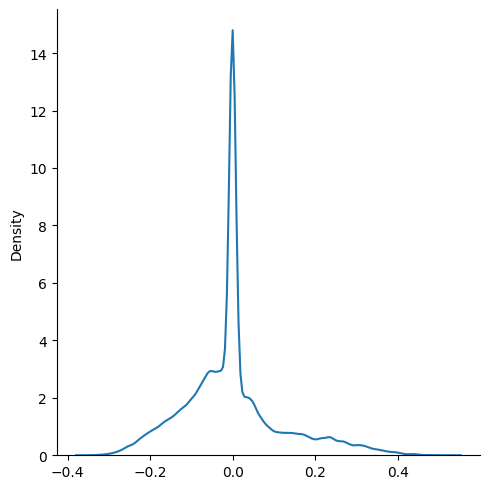

In [404]:
# Plot distribution of output values in a bell curve
from seaborn import displot

displot(raw_df[value_columns].to_numpy().flatten(), kind="kde")
plt.show()


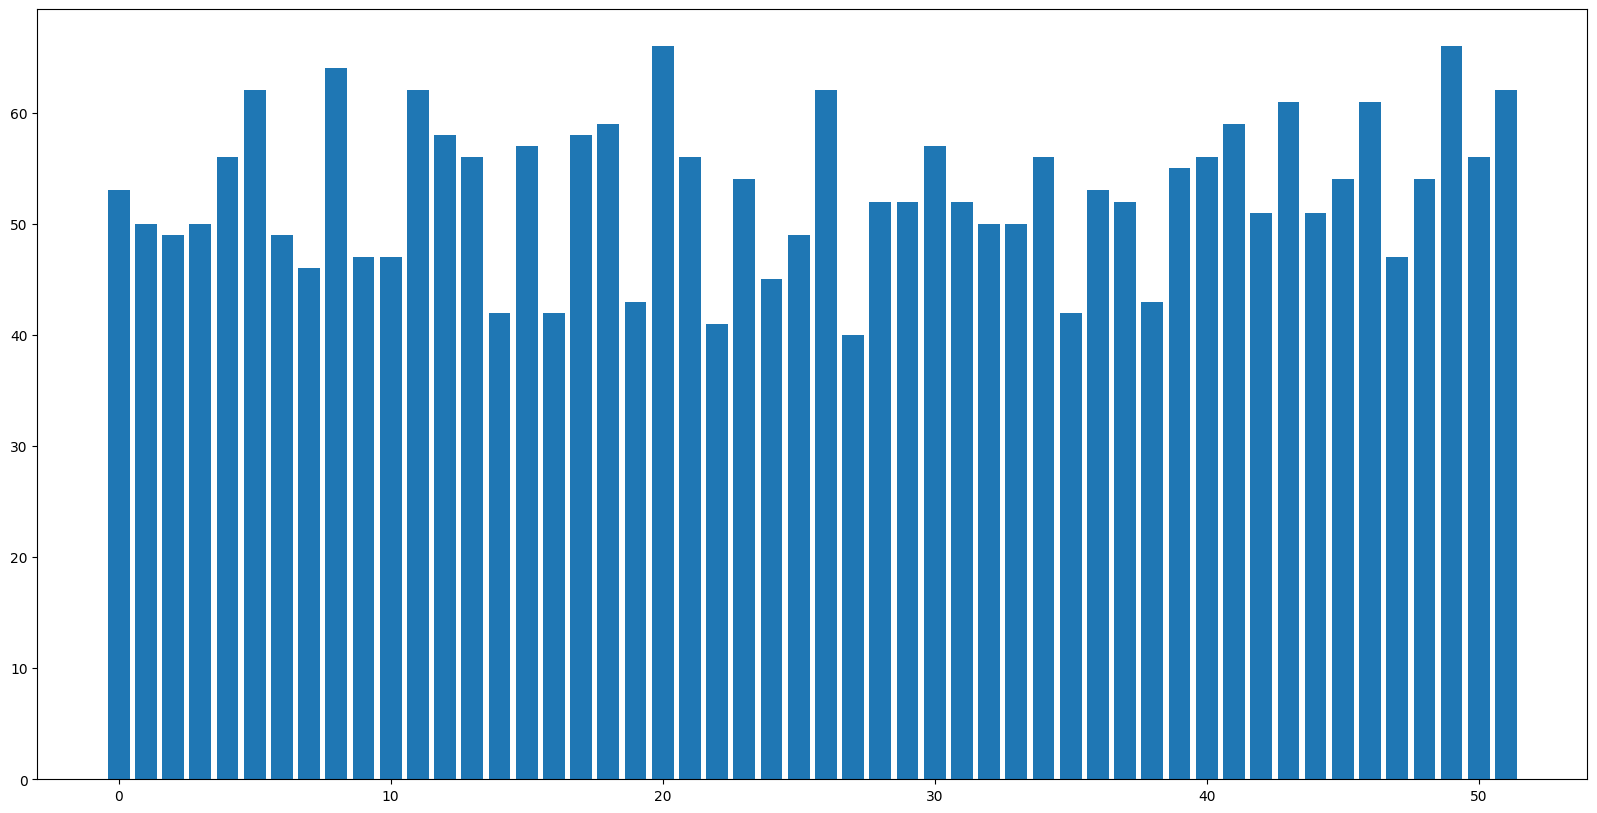

In [405]:
# Check representation of possible public cards
card_cols = [col for col in df.columns if col.startswith("public_card_")]
card_counts = df[card_cols].sum()
fig, ax = plt.subplots(figsize=(20, 10))
plt.bar(range(len(card_counts)), card_counts)
plt.show()

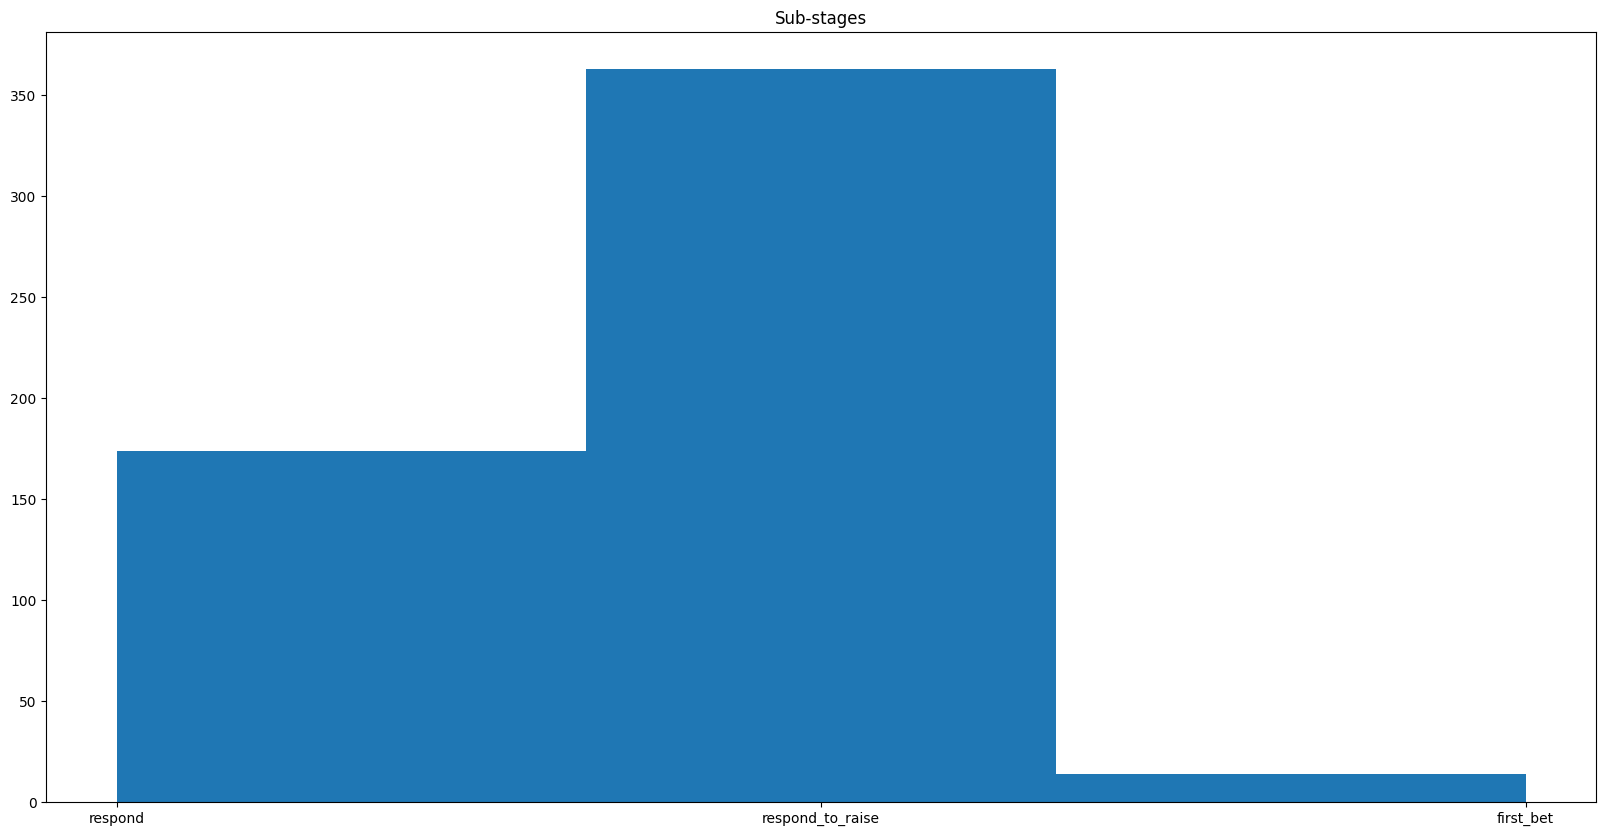

In [406]:
sub_stages = np.where(
    df["player_has_bet"] & df["opponent_has_bet"],
    "respond_to_raise",
    np.where(
        df["opponent_has_bet"],
        "respond",
        "first_bet"
    )
)
fig, ax = plt.subplots(figsize=(20, 10))
plt.hist(sub_stages, bins=3)
plt.title("Sub-stages")
plt.show()

In [407]:
Y_columns = [col for col in df.columns if col.startswith('value_of_hand_')]
X_columns = [col for col in df.columns if col not in Y_columns]
X = df[X_columns].values
Y = df[Y_columns].values
print(X.shape, Y.shape)

(551, 2712) (551, 1326)


### Structure for Neural Network

In [408]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [409]:
def generate_model():
    # Define input layer
    input_layer = Input(shape=(X.shape[1],), name="input_layer")

    # Define hidden layers
    hidden_layer_1 = Dense(128, activation="relu", name="hidden_layer_1")(input_layer)
    hidden_layer_2 = Dense(64, activation="relu", name="hidden_layer_2")(hidden_layer_1)
    hidden_layer_3 = Dense(32, activation="relu", name="hidden_layer_3")(hidden_layer_2)

    # Define value layer for player 1
    value_layer_P1 = Dense(Y.shape[1], activation="linear", name="value_layer_P1")(
        hidden_layer_3
    )

    model = Model(inputs=input_layer, outputs=value_layer_P1)
    model.compile(optimizer='adam', loss='mean_squared_error')

    return model

### Cross validation

In [410]:
# Split the data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Set up K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# This will store the fold results
fold_results = []

# Define the early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',      # Monitor the validation loss
    patience=5,              # Number of epochs with no improvement after which training will be stopped
    verbose=1,               # To print the message when stopping
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
)

# Loop over each fold
for i, (train_index, val_index) in enumerate(kf.split(X_train)):
    # Split the data into k-fold training and validation sets
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    Y_train_fold, Y_val_fold = Y_train[train_index], Y_train[val_index]

    print("@@@ FOLD", i+1, "@@@")
    print("Size of training set:", X_train_fold.shape[0])
    
    # Define and compile the neural network inside the loop to reset weights for each fold
    model = generate_model()
    
    # Train the model
    history = model.fit(
        X_train_fold, Y_train_fold,
        epochs=1000,
        validation_data=(X_val_fold, Y_val_fold),
        callbacks=[early_stopping]  # Include the early stopping callback here
    )
    
    # Save the history in fold_results
    fold_results.append(history.history)

@@@ FOLD 1 @@@
Size of training set: 352
Epoch 1/1000


2024-04-29 18:34:59.751923: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


11/11 [==============================] - 1s 57ms/step - loss: 0.1283 - val_loss: 0.0969
Epoch 2/1000


2024-04-29 18:35:00.500695: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


11/11 [==============================] - 0s 23ms/step - loss: 0.0667 - val_loss: 0.0617
Epoch 3/1000
11/11 [==============================] - 0s 22ms/step - loss: 0.0412 - val_loss: 0.0459
Epoch 4/1000
11/11 [==============================] - 0s 20ms/step - loss: 0.0305 - val_loss: 0.0370
Epoch 5/1000
11/11 [==============================] - 0s 19ms/step - loss: 0.0248 - val_loss: 0.0317
Epoch 6/1000
11/11 [==============================] - 0s 22ms/step - loss: 0.0216 - val_loss: 0.0284
Epoch 7/1000
11/11 [==============================] - 0s 20ms/step - loss: 0.0195 - val_loss: 0.0260
Epoch 8/1000
11/11 [==============================] - 0s 19ms/step - loss: 0.0181 - val_loss: 0.0241
Epoch 9/1000
11/11 [==============================] - 0s 19ms/step - loss: 0.0169 - val_loss: 0.0228
Epoch 10/1000
11/11 [==============================] - 0s 21ms/step - loss: 0.0160 - val_loss: 0.0216
Epoch 11/1000
11/11 [==============================] - 0s 17ms/step - loss: 0.0154 - val_loss: 0.0208
E

...

11/11 [==============================] - 0s 26ms/step - loss: 0.0739 - val_loss: 0.0608
Epoch 3/1000
11/11 [==============================] - 0s 21ms/step - loss: 0.0457 - val_loss: 0.0451
Epoch 4/1000
11/11 [==============================] - 0s 20ms/step - loss: 0.0339 - val_loss: 0.0359
Epoch 5/1000
11/11 [==============================] - 0s 20ms/step - loss: 0.0278 - val_loss: 0.0306
Epoch 6/1000
11/11 [==============================] - 0s 23ms/step - loss: 0.0241 - val_loss: 0.0270
Epoch 7/1000
11/11 [==============================] - 0s 18ms/step - loss: 0.0215 - val_loss: 0.0244
Epoch 8/1000
11/11 [==============================] - 0s 22ms/step - loss: 0.0197 - val_loss: 0.0224
Epoch 9/1000
11/11 [==============================] - 0s 20ms/step - loss: 0.0184 - val_loss: 0.0209
Epoch 10/1000
11/11 [==============================] - 0s 19ms/step - loss: 0.0173 - val_loss: 0.0197
Epoch 11/1000
11/11 [==============================] - 0s 20ms/step - loss: 0.0164 - val_loss: 0.0187
E

2024-04-29 18:35:36.194827: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


11/11 [==============================] - 1s 46ms/step - loss: 0.1321 - val_loss: 0.0974
Epoch 2/1000
 1/11 [=>............................] - ETA: 0s - loss: 0.0774

2024-04-29 18:35:36.754387: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


11/11 [==============================] - 0s 26ms/step - loss: 0.0710 - val_loss: 0.0615
Epoch 3/1000
11/11 [==============================] - 0s 20ms/step - loss: 0.0448 - val_loss: 0.0443
Epoch 4/1000
11/11 [==============================] - 0s 24ms/step - loss: 0.0324 - val_loss: 0.0350
Epoch 5/1000
11/11 [==============================] - 0s 19ms/step - loss: 0.0259 - val_loss: 0.0295
Epoch 6/1000
11/11 [==============================] - 0s 21ms/step - loss: 0.0223 - val_loss: 0.0261
Epoch 7/1000
11/11 [==============================] - 0s 20ms/step - loss: 0.0202 - val_loss: 0.0236
Epoch 8/1000
11/11 [==============================] - 0s 24ms/step - loss: 0.0186 - val_loss: 0.0217
Epoch 9/1000
11/11 [==============================] - 0s 20ms/step - loss: 0.0174 - val_loss: 0.0203
Epoch 10/1000
11/11 [==============================] - 0s 18ms/step - loss: 0.0165 - val_loss: 0.0193
Epoch 11/1000
11/11 [==============================] - 0s 21ms/step - loss: 0.0158 - val_loss: 0.0183
E

In [411]:
mse_scores = []

# Evaluate each fold
for fold_history in fold_results:
    val_mse_per_epoch = fold_history['val_loss']
    mse_scores.append(val_mse_per_epoch[-1])  # Take the last epoch MSE

# Calculate the average and standard deviation of the MSE scores across all folds
average_mse = np.mean(mse_scores)
std_dev_mse = np.std(mse_scores)

print(f"Cross-Validation MSE: {average_mse:.4f} (+/- {std_dev_mse:.4f})")
rmse = np.sqrt(average_mse)
rmse_std_dev = np.sqrt(std_dev_mse)
print(f"Cross-Validation RMSE: {rmse:.4f} (+/- {rmse_std_dev:.4f})")

Cross-Validation MSE: 0.0154 (+/- 0.0008)
Cross-Validation RMSE: 0.1242 (+/- 0.0280)


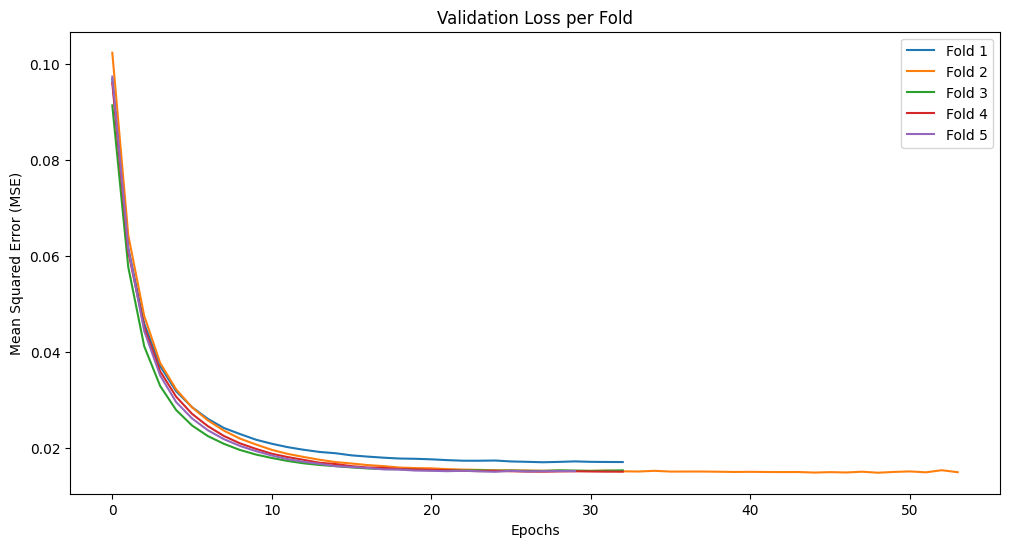

In [412]:
plt.figure(figsize=(12, 6))
for i, fold_history in enumerate(fold_results, 1):
    plt.plot(fold_history['val_loss'], label=f'Fold {i}')

plt.title('Validation Loss per Fold')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.show()

In [413]:
# Find optimal number of epochs
optimal_epochs = []

for result in fold_results:
    val_loss_per_epoch = result['val_loss']
    best_epoch = val_loss_per_epoch.index(min(val_loss_per_epoch))
    optimal_epochs.append(best_epoch)

average_optimal_epoch = np.mean(optimal_epochs)
buffer = 5  # Add a small buffer to avoid underfitting
final_epoch_number = int(average_optimal_epoch + buffer)

print(f"Suggested number of epochs for final training: {final_epoch_number}")

Suggested number of epochs for final training: 35


### Testing

In [414]:
# Test the model
model = generate_model()
model.fit(X_train, Y_train, epochs=final_epoch_number)
test_loss = model.evaluate(X_test, Y_test)
print(f"Test MSE: {test_loss:.4f}")
print(f"Test RMSE: {np.sqrt(test_loss):.4f}")

Epoch 1/35


2024-04-29 18:36:14.837938: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


14/14 [==============================] - 1s 31ms/step - loss: 0.1219
Epoch 2/35
14/14 [==============================] - 0s 20ms/step - loss: 0.0585
Epoch 3/35
14/14 [==============================] - 0s 23ms/step - loss: 0.0352
Epoch 4/35
14/14 [==============================] - 0s 19ms/step - loss: 0.0264
Epoch 5/35
14/14 [==============================] - 0s 15ms/step - loss: 0.0220
Epoch 6/35
14/14 [==============================] - 0s 17ms/step - loss: 0.0194
Epoch 7/35
14/14 [==============================] - 0s 14ms/step - loss: 0.0177
Epoch 8/35
14/14 [==============================] - 0s 16ms/step - loss: 0.0165
Epoch 9/35
14/14 [==============================] - 0s 18ms/step - loss: 0.0156
Epoch 10/35
14/14 [==============================] - 0s 17ms/step - loss: 0.0150
Epoch 11/35
14/14 [==============================] - 0s 17ms/step - loss: 0.0145
Epoch 12/35
14/14 [==============================] - 0s 15ms/step - loss: 0.0140
Epoch 13/35
14/14 [=============================

2024-04-29 18:36:22.115554: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


### Training of final model

In [386]:
# Train model on all data
model = generate_model()
model.fit(X, Y, epochs=final_epoch_number)

# Change working directory to models
os.chdir("models")

# Save the model
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
model_fname = f"model_{stage}_{timestamp}.h5"
model.save(model_fname)

# Save metadata
metadata = {
    "mean_training_range_val": mean_training_range_val,
    "sd_training_range_val": sd_training_range_val,
}
meta_fname = f"model_{stage}_{timestamp}.json"
with open(meta_fname, "w") as f:
    json.dump(metadata, f)

# Symlink the model to the latest model
latest_fname = f"model_{stage}_latest.h5"
latest_meta_fname = f"model_{stage}_latest.json"
if os.path.exists(latest_fname):
    os.remove(latest_fname)
if os.path.exists(latest_meta_fname):
    os.remove(latest_meta_fname)
os.symlink(model_fname, latest_fname)
os.symlink(meta_fname, latest_meta_fname)

# Change working directory back to parent
os.chdir("..")

Epoch 1/42


2024-04-29 18:04:43.483111: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


13/13 [==============================] - 1s 40ms/step - loss: 0.1260
Epoch 2/42
13/13 [==============================] - 0s 25ms/step - loss: 0.0658
Epoch 3/42
13/13 [==============================] - 0s 16ms/step - loss: 0.0395
Epoch 4/42
13/13 [==============================] - 0s 18ms/step - loss: 0.0288
Epoch 5/42
13/13 [==============================] - 0s 14ms/step - loss: 0.0234
Epoch 6/42
13/13 [==============================] - 0s 17ms/step - loss: 0.0203
Epoch 7/42
13/13 [==============================] - 0s 19ms/step - loss: 0.0184
Epoch 8/42
13/13 [==============================] - 0s 16ms/step - loss: 0.0171
Epoch 9/42
13/13 [==============================] - 0s 16ms/step - loss: 0.0162
Epoch 10/42
13/13 [==============================] - 0s 17ms/step - loss: 0.0154
Epoch 11/42
13/13 [==============================] - 0s 21ms/step - loss: 0.0149
Epoch 12/42
13/13 [==============================] - 0s 17ms/step - loss: 0.0144
Epoch 13/42
13/13 [=============================